# Week 9 Lecture 3 — Concept drift on real investment data

**DATAX504** · Companion to `slides/week09/lecture3.pdf`

Instructor-led walkthrough. Students watch / ask questions. Optional BYOD follow-along.

Chapter 13 taught windows, baselines, and RNNs. This lab asks the next question:
**what if the world changes after you train?**

| Step | Topic |
|------|--------|
| 1 | Load SPY daily prices (S&P 500 ETF) |
| 2 | Build a short return window → next-day return |
| 3 | Train early (2015–2018), score later years |
| 4 | See volatility regimes (COVID, rate hikes) |
| 5 | Walk-forward evaluation |
| 6 | Rolling retrain |
| 7 | Compare strategies and write takeaways |

**Framing:** this is about evaluation honesty under drift, not a trading system.
Predicting next-day returns is hard. Beating "predict zero" is rare. That is part of the lesson.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

ROOT = Path("..")
DATA = ROOT / "data" / "spy_daily.csv"
LOOKBACK = 20

print("data path:", DATA.resolve())

data path: /Users/eva/Documents/Assignments/DATAX504/data/spy_daily.csv


## Step 1 — Load SPY

Download once with `yfinance` and save it.

In [3]:
def load_spy(path: Path = DATA) -> pd.DataFrame:
    if path.exists():
        df = pd.read_csv(path, parse_dates=["Date"])
        print("Loaded cache:", path)
    else:
        import yfinance as yf

        raw = yf.download(
            "SPY", start="2015-01-01", end="2024-12-31",
            progress=False, auto_adjust=True,
        )
        if hasattr(raw.columns, "levels"):
            raw.columns = [c[0] if isinstance(c, tuple) else c for c in raw.columns]
        df = raw.reset_index()
        path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(path, index=False)
        print("Downloaded and cached:", path)

    df = df.sort_values("Date").reset_index(drop=True)
    df["ret"] = np.log(df["Close"]).diff()
    df["vol21"] = df["ret"].rolling(21).std()
    return df.dropna().reset_index(drop=True)


df = load_spy()
print(df[["Date", "Close", "ret", "vol21"]].head(3))
print(f"{len(df)} trading days: {df.Date.min().date()} → {df.Date.max().date()}")

Downloaded and cached: ../data/spy_daily.csv
        Date       Close       ret     vol21
0 2015-02-03  168.781418  0.014358  0.011266
1 2015-02-04  168.138687 -0.003815  0.010524
2 2015-02-05  169.836014  0.010044  0.010457
2494 trading days: 2015-02-03 → 2024-12-30


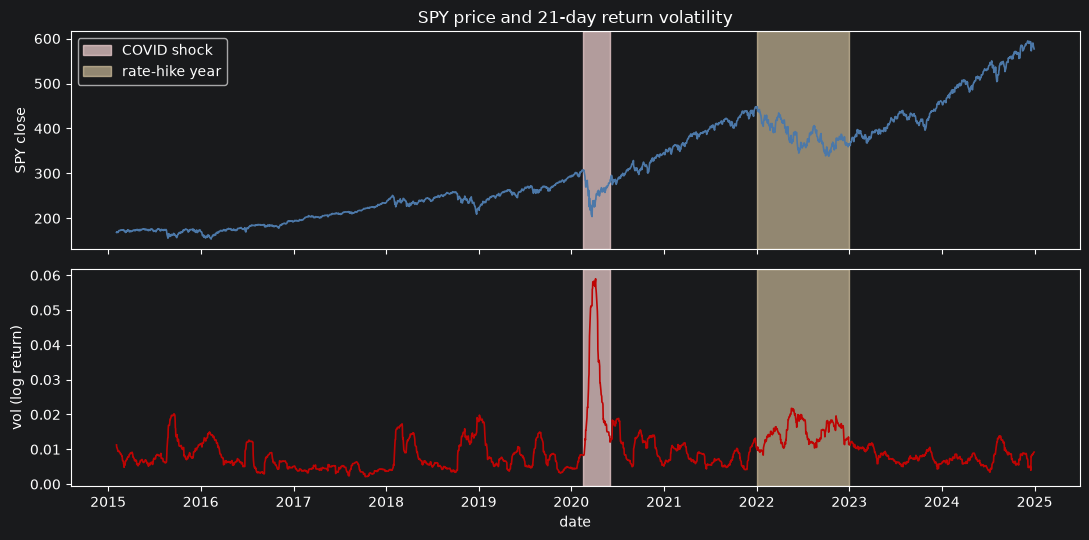

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)

axes[0].plot(df["Date"], df["Close"], color="#4C78A8", lw=1.2)
axes[0].set_ylabel("SPY close")
axes[0].set_title("SPY price and 21-day return volatility")

axes[1].plot(df["Date"], df["vol21"], color="#BE0403", lw=1.2)
axes[1].set_ylabel("vol (log return)")
axes[1].set_xlabel("date")

for ax in axes:
    ax.axvspan(pd.Timestamp("2020-02-15"), pd.Timestamp("2020-06-01"),
               color="#F4D4D4", alpha=0.7, label="COVID shock")
    ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31"),
               color="#F7E2B8", alpha=0.55, label="rate-hike year")

axes[0].legend(loc="upper left")
plt.tight_layout()
plt.show()

## Step 2 — Windows from returns

Predict **tomorrow's log return** from the last `LOOKBACK` daily returns.

Returns are closer to stationary than raw prices. That is already one drift mitigator.

In [5]:
rets = df["ret"].to_numpy()
dates = df["Date"].to_numpy()

X_list, y_list, d_list = [], [], []
for i in range(LOOKBACK, len(rets)):
    X_list.append(rets[i - LOOKBACK : i])
    y_list.append(rets[i])
    d_list.append(dates[i])

X = np.asarray(X_list)
y = np.asarray(y_list)
y_dates = pd.to_datetime(np.asarray(d_list))
years = y_dates.year.to_numpy()

print("X shape:", X.shape, "  y shape:", y.shape)
print("Target years:", years.min(), "→", years.max())

X shape: (2474, 20)   y shape: (2474,)
Target years: 2015 → 2024


## Step 3 — Static early → late split

Train once on 2015–2018. Score each later year separately.

Also report a **naive baseline**: always predict return = 0 (no change).

In [6]:
def year_mask(lo: int, hi: int) -> np.ndarray:
    return (years >= lo) & (years <= hi)


def fit_predict(X_train, y_train, X_test):
    """Ridge on standardised windows. Fast stand-in for a small Dense net."""
    scaler = StandardScaler()
    Xt = scaler.fit_transform(X_train)
    Xs = scaler.transform(X_test)
    model = Ridge(alpha=1.0)
    model.fit(Xt, y_train)
    return model.predict(Xs)


def mae(a, b) -> float:
    return float(np.mean(np.abs(a - b)))


def dir_acc(pred, true) -> float:
    return float(np.mean(np.sign(pred) == np.sign(true)))


train_m = year_mask(2015, 2018)
rows = []
for yr in range(2019, 2025):
    te = year_mask(yr, yr)
    pred = fit_predict(X[train_m], y[train_m], X[te])
    rows.append({
        "test_year": yr,
        "n": int(te.sum()),
        "model_MAE": mae(pred, y[te]),
        "naive0_MAE": mae(np.zeros(te.sum()), y[te]),
        "dir_acc": dir_acc(pred, y[te]),
        "mean_|ret|": float(np.mean(np.abs(y[te]))),
    })

static = pd.DataFrame(rows)
static

,test_year,n,model_MAE,naive0_MAE,dir_acc,mean_|ret|
0,2019,252,0.005780,0.005682,0.547619,0.005682
1,2020,253,0.013316,0.013294,0.501976,0.013294
2,2021,252,0.006502,0.006271,0.492063,0.006271
3,2022,251,0.012012,0.012002,0.505976,0.012002
4,2023,250,0.006583,0.006477,0.532000,0.006477
5,2024,251,0.006014,0.005889,0.509960,0.005889


### What to notice

- Calm years (2019, 2021, 2023–24): smaller MAE.
- Shock years (2020, 2022): MAE roughly doubles.
- Model MAE sits near naive-zero MAE. The series is close to unpredictable day-to-day.
- If you only reported 2019, you would overstate how well the static model travels.

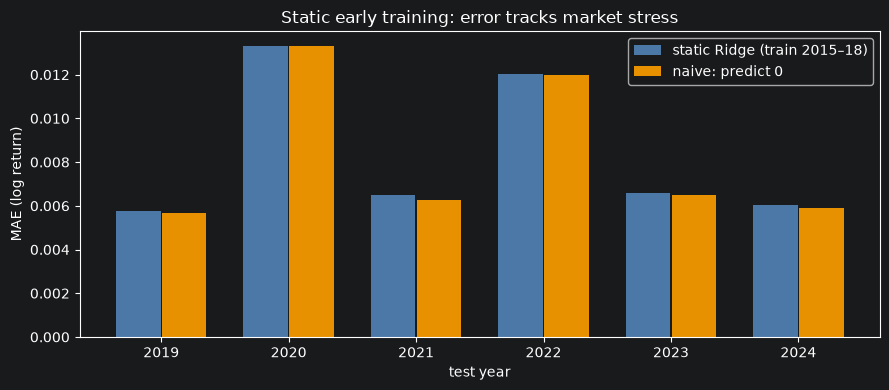

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(static["test_year"] - 0.18, static["model_MAE"], width=0.35,
       label="static Ridge (train 2015–18)", color="#4C78A8")
ax.bar(static["test_year"] + 0.18, static["naive0_MAE"], width=0.35,
       label="naive: predict 0", color="#E79000")
ax.set_xlabel("test year")
ax.set_ylabel("MAE (log return)")
ax.set_title("Static early training: error tracks market stress")
ax.legend()
plt.tight_layout()
plt.show()

## Step 4 — Monitor drift

A simple detector: rolling MAE of the **frozen** model on a trailing window.
When it stays high, the operating regime has changed.

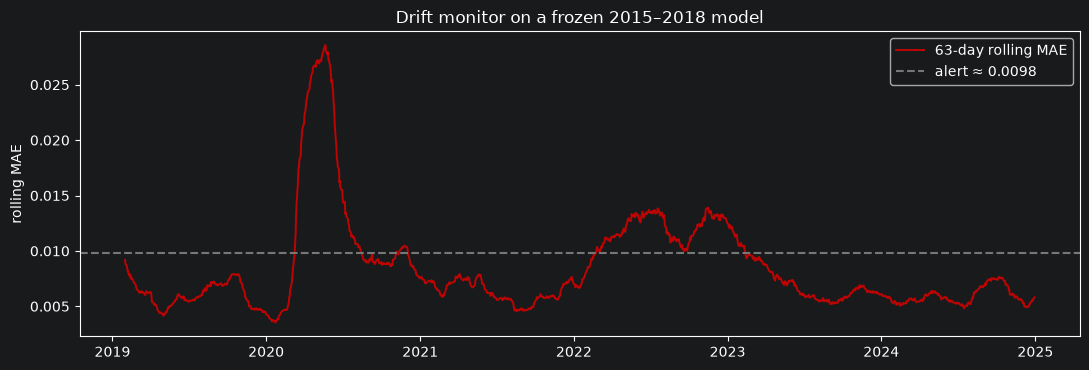

Days above threshold: 372 / 1489


In [8]:
later = years >= 2019
pred_later = fit_predict(X[train_m], y[train_m], X[later])
abs_err = np.abs(pred_later - y[later])

roll = pd.Series(abs_err, index=y_dates[later]).rolling(63, min_periods=21).mean()
threshold = float(roll.dropna().quantile(0.75))

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(roll.index, roll.values, color="#BE0403", lw=1.4, label="63-day rolling MAE")
ax.axhline(threshold, color="#777777", ls="--", label=f"alert ≈ {threshold:.4f}")
ax.set_title("Drift monitor on a frozen 2015–2018 model")
ax.set_ylabel("rolling MAE")
ax.legend()
plt.tight_layout()
plt.show()

print("Days above threshold:", int((roll > threshold).sum()), "/", roll.notna().sum())

## Step 5 — Walk-forward evaluation

For each year, train only on the **past**, then score that year.
No peeking at future regimes during training.

In [ ]:
wf_rows = []
for yr in range(2019, 2025):
    tr = years < yr
    te = year_mask(yr, yr)
    pred = fit_predict(X[tr], y[tr], X[te])
    wf_rows.append({
        "test_year": yr,
        "train_through": yr - 1,
        "model_MAE": mae(pred, y[te]),
        "naive0_MAE": mae(np.zeros(te.sum()), y[te]),
        "dir_acc": dir_acc(pred, y[te]),
    })

walk = pd.DataFrame(wf_rows)
walk

## Step 6 — Rolling retrain (recent window only)

Retrain each year on the **previous three years** only.
Old calm data does not dominate the fit after a regime change.

In [ ]:
roll_rows = []
for yr in range(2019, 2025):
    tr = year_mask(yr - 3, yr - 1)
    te = year_mask(yr, yr)
    pred = fit_predict(X[tr], y[tr], X[te])
    roll_rows.append({
        "test_year": yr,
        "train_window": f"{yr-3}–{yr-1}",
        "model_MAE": mae(pred, y[te]),
        "naive0_MAE": mae(np.zeros(te.sum()), y[te]),
        "dir_acc": dir_acc(pred, y[te]),
    })

rolling = pd.DataFrame(roll_rows)
rolling

## Step 7 — Compare strategies

In [ ]:
cmp = pd.DataFrame({
    "year": static["test_year"],
    "static_MAE": static["model_MAE"],
    "walkforward_MAE": walk["model_MAE"],
    "rolling_retrain_MAE": rolling["model_MAE"],
    "naive0_MAE": static["naive0_MAE"],
    "static_dir": static["dir_acc"],
    "rolling_dir": rolling["dir_acc"],
})
cmp

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
w = 0.22
yrs = cmp["year"].to_numpy()
ax.bar(yrs - 1.5 * w, cmp["static_MAE"], width=w, label="static 2015–18", color="#4C78A8")
ax.bar(yrs - 0.5 * w, cmp["walkforward_MAE"], width=w, label="walk-forward", color="#59A14F")
ax.bar(yrs + 0.5 * w, cmp["rolling_retrain_MAE"], width=w, label="rolling 3y", color="#E79000")
ax.bar(yrs + 1.5 * w, cmp["naive0_MAE"], width=w, label="naive 0", color="#777777")
ax.set_xlabel("test year")
ax.set_ylabel("MAE (log return)")
ax.set_title("Strategy comparison under regime shifts")
ax.legend(ncols=2)
plt.tight_layout()
plt.show()

print("Mean MAE across 2019–2024")
print(cmp[["static_MAE", "walkforward_MAE", "rolling_retrain_MAE", "naive0_MAE"]].mean().round(5))

## Takeaways for projects

1. **Order splits are necessary but not sufficient.** A single late test year can hide earlier luck.
2. **Monitor live error.** Rolling MAE (or calibration) is a cheap drift alarm.
3. **Retrain on recent data** when the process can change (markets, demand, sensors).
4. **Prefer stationary features** (returns, differences) over raw levels when possible.
5. **Keep a strong naive baseline.** If you cannot beat "predict zero", say so.
6. **Proposal tip:** if your project is timeseries, write how you will handle drift in evaluation.

### Optional extensions

- Swap Ridge for a small Keras `Dense` or `LSTM` (same windows).
- Add volume / high-low range as multivariate inputs.
- Try a volatility-scaled target: `ret / vol21` so MAE is less regime-dominated.
- Try another ticker (`QQQ`, `EFA`) and compare which years break.